In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vamsinossam/dataset-view/US_Accidents_March23.csv


In [2]:
pip install pandas numpy matplotlib seaborn folium

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [4]:
df = pd.read_csv("/kaggle/input/datasets/vamsinossam/dataset-view/US_Accidents_March23.csv")

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [5]:
print(df.shape)

(7728394, 46)


In [6]:
df = df[['Start_Time','Weather_Condition','Severity',
         'Start_Lat','Start_Lng','Temperature(F)',
         'Visibility(mi)']]

In [7]:
# Convert Start_Time safely
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract hour of accident
df['Hour'] = df['Start_Time'].dt.hour

# Check result
df[['Start_Time','Hour']].head()

,Start_Time,Hour
0,2016-02-08 05:46:00,5.0
1,2016-02-08 06:07:59,6.0
2,2016-02-08 06:49:27,6.0
3,2016-02-08 07:23:34,7.0
4,2016-02-08 07:39:07,7.0


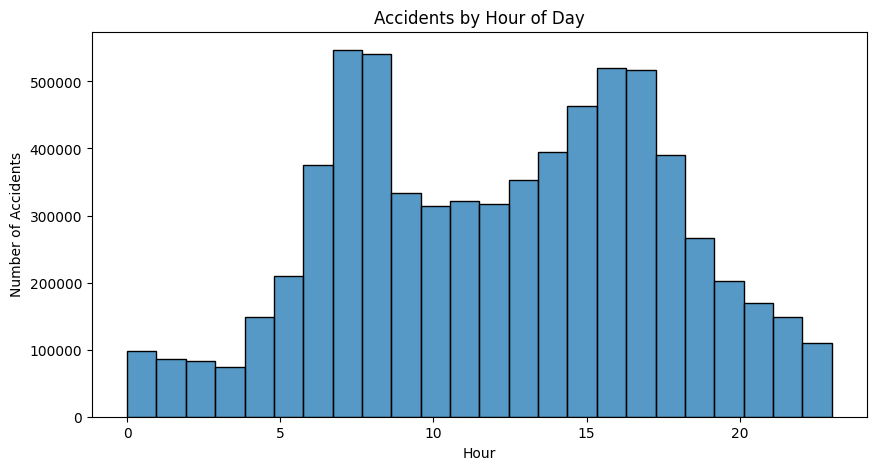

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(df['Hour'], bins=24)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.show()

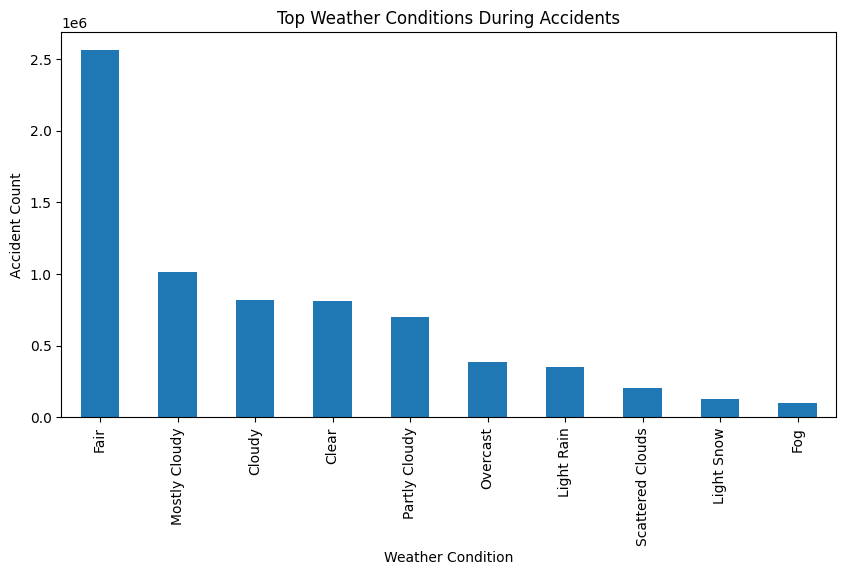

In [9]:
weather_counts = df['Weather_Condition'].value_counts().head(10)

weather_counts.plot(kind='bar', figsize=(10,5))

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Count")

plt.show()

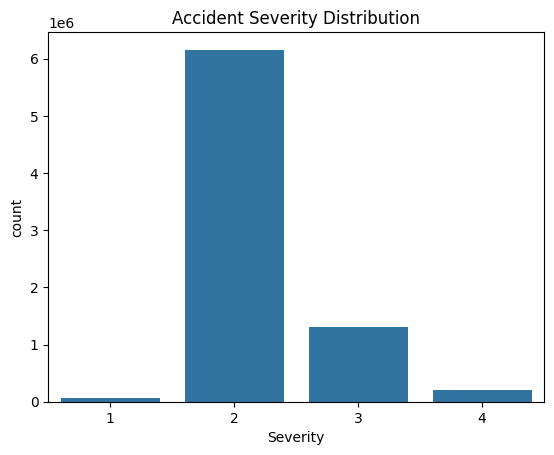

In [10]:
sns.countplot(x='Severity', data=df)

plt.title("Accident Severity Distribution")

plt.show()

In [11]:
sample = df.sample(2000)

accident_map = folium.Map(
    location=[sample['Start_Lat'].mean(),
              sample['Start_Lng'].mean()],
    zoom_start=4
)

for index,row in sample.iterrows():
    folium.CircleMarker(
        location=[row['Start_Lat'],row['Start_Lng']],
        radius=2,
        color='red'
    ).add_to(accident_map)

accident_map

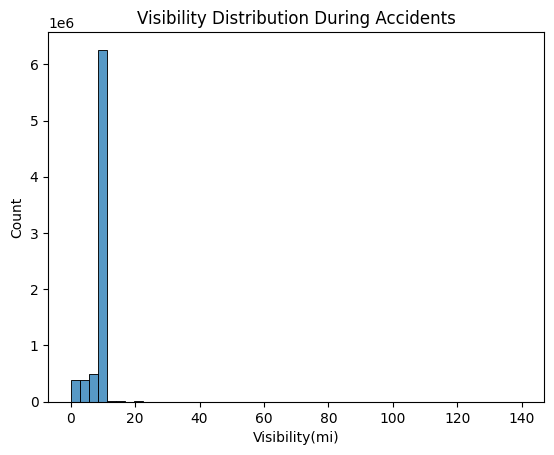

In [12]:
sns.histplot(df['Visibility(mi)'], bins=50)

plt.title("Visibility Distribution During Accidents")

plt.show()

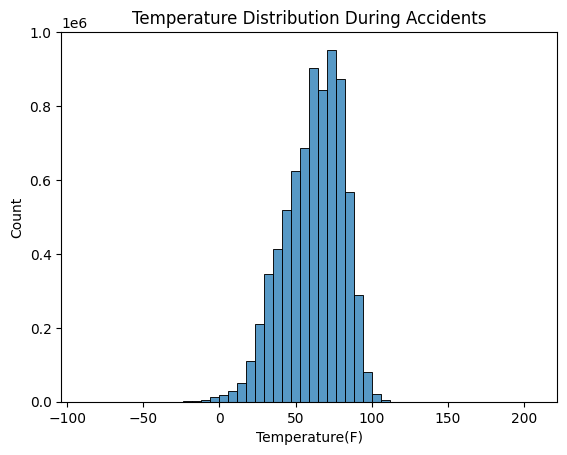

In [13]:
sns.histplot(df['Temperature(F)'], bins=50)

plt.title("Temperature Distribution During Accidents")

plt.show()